# 03 – Genetic Algorithm for Playlist Optimization
**Project**: Playlist Optimizer  
**Author**: S33mi  

Optimize an ordered playlist with a Genetic Algorithm.

- Chromosome = ordered list of unique track indices (fixed length)
- Fitness = `total_playlist_score` (smoothness + seed similarity + diversity + mood)
- Operators: tournament selection, order crossover (OX), swap / insertion mutation

Data is loaded via **URL method** (Colab-friendly).

## 1. Setup & Imports

In [211]:
import os
from io import BytesIO
import random
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import joblib
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_colwidth", 90)

print("Libraries loaded.")

Libraries loaded.


## 2. Load Artifacts via URL

In [212]:
BASE = "https://raw.githubusercontent.com/S33mi/spotify-music-recommender/main"

URL_PART1 = f"{BASE}/data/processed/spotify_with_clusters_part1.csv"
URL_PART2 = f"{BASE}/data/processed/spotify_with_clusters_part2.csv"
URL_X     = f"{BASE}/data/processed/X_scaled.npy"
URL_MOOD  = f"{BASE}/data/models/mood_labels.pkl"

def download(url: str) -> bytes:
    print(f"Downloading {url} ...")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    return r.content

# DataFrame
print("Loading track metadata ...")
p1 = download(URL_PART1)
p2 = download(URL_PART2)
with open("_part1.tmp", "wb") as f: f.write(p1)
with open("_part2.tmp", "wb") as f: f.write(p2)
df = pd.concat([pd.read_csv("_part1.tmp"), pd.read_csv("_part2.tmp")], ignore_index=True)
os.remove("_part1.tmp"); os.remove("_part2.tmp")

# Feature matrix
X = np.load(BytesIO(download(URL_X)))

# Mood labels
mood_labels = joblib.load(BytesIO(download(URL_MOOD)))
if "mood" not in df.columns and "cluster" in df.columns:
    df["mood"] = df["cluster"].map(mood_labels)

assert len(df) == len(X)
print(f"Loaded {len(df)} tracks | X shape = {X.shape}")

Loading track metadata ...
Loaded 89741 tracks | X shape = (89741, 10)


## 3. Scoring Functions (same as previous notebooks with some updates to avoid NaN values)


In [213]:
#Updated
def playlist_energy_tempo(df, indices):
    """Safely extract energy and tempo, filling missing values."""
    energy = df.iloc[indices]["energy"].values if "energy" in df.columns else np.zeros(len(indices))
    tempo  = df.iloc[indices]["tempo"].values  if "tempo"  in df.columns else np.zeros(len(indices))

    # Fill NaNs with column median (or 0.5 / 120 as reasonable defaults)
    energy = np.nan_to_num(energy, nan=np.nanmedian(energy) if not np.all(np.isnan(energy)) else 0.5)
    tempo  = np.nan_to_num(tempo,  nan=np.nanmedian(tempo)  if not np.all(np.isnan(tempo))  else 120.0)

    return energy.astype(float), tempo.astype(float)

#updated
def smoothness_score(energy, tempo, w_energy=0.6, w_tempo=0.4):
    """Robust smoothness score that never returns NaN."""
    if len(energy) < 2:
        return 1.0

    # Extra safety
    energy = np.nan_to_num(energy, nan=0.5)
    tempo  = np.nan_to_num(tempo,  nan=120.0)

    e_jump = np.abs(np.diff(energy)).mean()
    t_jump = (np.abs(np.diff(tempo)) / 50.0).mean()

    score = 1.0 / (1.0 + w_energy * e_jump + w_tempo * t_jump)

    # Final protection
    if np.isnan(score) or np.isinf(score):
        return 0.5
    return float(score)

def seed_similarity_score(X, seed_idx, playlist_indices):
    sims = cosine_similarity(X[seed_idx].reshape(1, -1), X[playlist_indices])[0]
    return float(sims.mean())

def diversity_score(X, playlist_indices):
    if len(playlist_indices) < 2:
        return 1.0
    sim = cosine_similarity(X[playlist_indices])
    triu = sim[np.triu_indices(len(playlist_indices), k=1)]
    return float(1.0 - triu.mean())

def mood_consistency_score(df, playlist_indices, seed_idx):
    if "mood" not in df.columns:
        return 0.5
    seed_mood = df.iloc[seed_idx]["mood"]
    return float((df.iloc[playlist_indices]["mood"] == seed_mood).mean())

#updated
def total_playlist_score(
    df, X, seed_idx, playlist_indices,
    w_smooth=0.30, w_sim=0.30, w_div=0.25, w_mood=0.15
):
    try:
        playlist_indices = [int(i) for i in playlist_indices]  # force integers

        energy, tempo = playlist_energy_tempo(df, playlist_indices)

        comps = {
            "smoothness":       smoothness_score(energy, tempo),
            "seed_similarity":  seed_similarity_score(X, seed_idx, playlist_indices),
            "diversity":        diversity_score(X, playlist_indices),
            "mood_consistency": mood_consistency_score(df, playlist_indices, seed_idx),
        }

        total = (
            w_smooth * comps["smoothness"]
            + w_sim   * comps["seed_similarity"]
            + w_div   * comps["diversity"]
            + w_mood  * comps["mood_consistency"]
        )

        # Final safety
        if np.isnan(total) or np.isinf(total):
            total = 0.0

        comps["total"] = float(total)
        return comps["total"], comps

    except Exception as e:
        print(f"Scoring error: {e}")
        return 0.0, {
            "smoothness": 0.0,
            "seed_similarity": 0.0,
            "diversity": 0.0,
            "mood_consistency": 0.0,
            "total": 0.0
        }

## 4. Display Helpers

In [214]:
def show_playlist(df, indices, title="Playlist"):
    cols = ["track_name", "artists", "track_genre", "popularity"]
    for c in ["mood", "energy", "tempo"]:
        if c in df.columns:
            cols.append(c)
    out = df.iloc[indices][cols].copy()
    out.index = range(1, len(out) + 1)
    print(title)
    display(out)
    return out

def plot_energy_tempo(df, indices, title="Energy & Tempo"):
    energy, tempo = playlist_energy_tempo(df, indices)
    x = np.arange(1, len(indices) + 1)
    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.plot(x, energy, "o-", color="steelblue")
    ax1.set_ylabel("Energy", color="steelblue")
    ax1.set_xlabel("Position")
    ax2 = ax1.twinx()
    ax2.plot(x, tempo, "s--", color="darkorange")
    ax2.set_ylabel("Tempo (BPM)", color="darkorange")
    plt.title(title)
    fig.tight_layout()
    plt.show()

## 5. Choose Seed & GA Hyperparameters

### Why Genetic Algorithm?
Genetic Algorithms are good when:
- The search space is extremely large
- The objective function is not differentiable
- We need a good balance between **exploration** and **exploitation**

In this project, a playlist of 12 tracks from ~thousands of songs creates a huge search space → GA is a suitable choice.

---
### Important Parameters & Their Meaning

- **Population Size (100)**: Larger → more diversity, slower
- **Generations (120)**: How long we evolve
- **Crossover Rate (0.85)**: Probability of combining two parents
- **Mutation Rate (0.18)**: Probability a child is mutated
- **N_Mutations (2)**: How strong each mutation is
- **Tournament Size (3)**: Higher = stronger selection pressure
- **Elite Size (4)**: Number of best solutions copied unchanged

**Rule of thumb**:
- Too high mutation → random search
- Too low mutation → stuck in local optima
- Too strong selection → premature convergence

In [215]:
SEED_QUERY = "blinding lights" #blinding lights
# PLAYLIST_LENGTH = 12

mask = (
    df["track_name"].str.lower().str.contains(SEED_QUERY.lower(), na=False) &
    ~df["artists"].str.lower().str.contains("kidz bop|kidzbop", na=False) &
    (df["popularity"] > 20)          # avoid zero-popularity tracks
)

if mask.sum() == 0:
    # fallback
    mask = df["track_name"].str.lower().str.contains(SEED_QUERY.lower(), na=False)

seed_pos = df.index.get_loc(mask.idxmax())
seed = df.iloc[seed_pos]

print("Seed track:")
print(f"  {seed['track_name']} — {seed['artists']}")
print(f"  Genre: {seed.get('track_genre')} | Mood: {seed.get('mood')} | Pop: {seed['popularity']:.1f}")

# GA parameters
# POP_SIZE = 60
# N_GENERATIONS = 80
# TOURNAMENT_SIZE = 3
# CROSSOVER_RATE = 0.85
# MUTATION_RATE = 0.25          # probability a child is mutated
# N_MUTATIONS = 5               # swaps / insertions per mutation event
# ELITE_SIZE = 2
RANDOM_STATE = 42

POP_SIZE = 100
N_GENERATIONS = 120
TOURNAMENT_SIZE = 3
CROSSOVER_RATE = 0.85
MUTATION_RATE = 0.18
N_MUTATIONS = 2
ELITE_SIZE = 4

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Seed track:
  Blinding Lights — Lucas Estrada;Twan Ray
  Genre: deep-house | Mood: Acoustic / Chill | Pop: 51.0


## 6. Genetic Operators

Key Components of Our GA

| Component              | What we used                          | Why |
|------------------------|---------------------------------------|-----|
| Representation         | List of unique track indices          | Natural for ordered playlist |
| Fitness                | Weighted sum of 4 scores              | Multi-objective → single score |
| Selection              | Tournament Selection (k=3)            | Simple + good selection pressure |
| Crossover              | Order Crossover (OX)                  | Preserves relative order & uniqueness |
| Mutation               | Swap + Replace                        | Maintains diversity |
| Elitism                | Keep top 4 individuals                | Never lose the best solution |


In [216]:
def create_individual(n_tracks, length, seed_idx):
    """Random playlist of `length` unique tracks (excluding seed)."""
    candidates = list(range(n_tracks))
    candidates.remove(seed_idx)
    return random.sample(candidates, length)

def create_population(n_tracks, length, seed_idx, pop_size):
    return [create_individual(n_tracks, length, seed_idx) for _ in range(pop_size)]

# def fitness(individual, df, X, seed_idx):
#    score, _ = total_playlist_score(df, X, seed_idx, individual)
#    return score

def fitness(individual, df, X, seed_idx):
    try:
        ind = [int(x) for x in individual]

        # Check validity
        if len(ind) != PLAYLIST_LENGTH:
            return -1.0
        if len(set(ind)) != len(ind):          # duplicates
            return -1.0
        if any(i < 0 or i >= len(df) or i == seed_idx for i in ind):
            return -1.0

        score, _ = total_playlist_score(df, X, seed_idx, ind)

        if np.isnan(score) or np.isinf(score):
            return -1.0
        return float(score)
    except:
        return -1.0

def tournament_selection(population, fitnesses, k=3):
    contenders = random.sample(list(zip(population, fitnesses)), k)
    contenders.sort(key=lambda x: x[1], reverse=True)
    return deepcopy(contenders[0][0])

def order_crossover(parent1, parent2):
    """
    Safe Order Crossover (OX).
    Preserves relative order and guarantees uniqueness.
    """
    size = len(parent1)
    a, b = sorted(random.sample(range(size), 2))

    child = [None] * size
    # copy segment from parent1
    child[a:b+1] = parent1[a:b+1]

    p2_filtered = [gene for gene in parent2 if gene not in child]

    # Safety: if something went wrong, just return a copy of parent1
    if len(p2_filtered) < size - (b - a + 1):
        return parent1[:]

    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = p2_filtered[idx]
            idx += 1
    return child

def mutate(individual, n_tracks, seed_idx, n_mutations=2):
    """
    Apply a few random moves:
    - swap two positions
    - or replace one track with a new unused track
    """
    ind = individual[:]
    length = len(ind)
    used = set(ind)

    for _ in range(n_mutations):
        if random.random() < 0.6:
            # swap
            i, j = random.sample(range(length), 2)
            ind[i], ind[j] = ind[j], ind[i]
        else:
            # replace one gene with an unused track
            pos = random.randrange(length)
            candidates = [t for t in range(n_tracks) if t != seed_idx and t not in used]
            if not candidates:
                break
            new_track = random.choice(candidates)
            used.remove(ind[pos])
            used.add(new_track)
            ind[pos] = new_track
    return ind

## 7. Run Genetic Algorithm


In [217]:
n_tracks = len(df)

population = create_population(n_tracks, PLAYLIST_LENGTH, seed_pos, POP_SIZE)
fitnesses = [fitness(ind, df, X, seed_pos) for ind in population]

best_fitness_history = []
mean_fitness_history = []
best_individual = None            # best_individual = deepcopy(population[np.argmax(fitnesses)])
best_fitness = -np.inf            # max(fitnesses)

print("Running Genetic Algorithm ...")
for gen in tqdm(range(N_GENERATIONS), desc="Generations"):
    # Elitism
    elite_idx = np.argsort(fitnesses)[-ELITE_SIZE:]
    new_population = [deepcopy(population[i]) for i in elite_idx]

    # Breed the rest
    while len(new_population) < POP_SIZE:
        parent1 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
        parent2 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)

        if random.random() < CROSSOVER_RATE:
            child = order_crossover(parent1, parent2)
        else:
            child = deepcopy(parent1)

        if random.random() < MUTATION_RATE:
            child = mutate(child, n_tracks, seed_pos, N_MUTATIONS)

        new_population.append(child)

    population = new_population
    fitnesses = [fitness(ind, df, X, seed_pos) for ind in population]

    gen_best = max(fitnesses)
    gen_mean = np.mean(fitnesses)
    best_fitness_history.append(gen_best)
    mean_fitness_history.append(gen_mean)

    if gen_best > best_fitness:
        best_fitness = gen_best
        best_individual = deepcopy(population[np.argmax(fitnesses)])

print(f"\nBest fitness found: {best_fitness:.4f}")


Running Genetic Algorithm ...


Generations:   0%|          | 0/120 [00:00<?, ?it/s]


Best fitness found: 0.7456


## 8. Convergence Plot


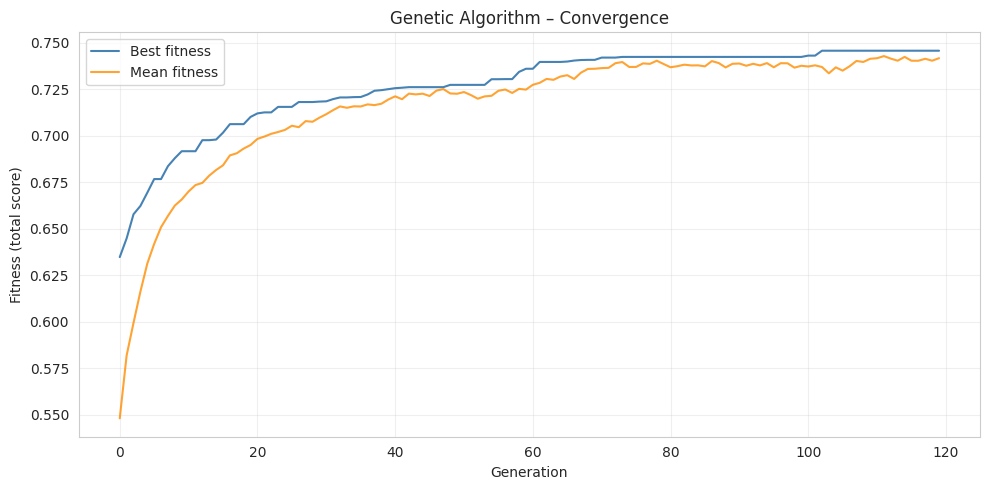

In [218]:
plt.figure(figsize=(10, 5))
plt.plot(best_fitness_history, label="Best fitness", color="steelblue")
plt.plot(mean_fitness_history, label="Mean fitness", color="darkorange", alpha=0.8)
plt.xlabel("Generation")
plt.ylabel("Fitness (total score)")
plt.title("Genetic Algorithm – Convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Best Playlist Found by GA

=== Genetic Algorithm – Best Playlist ===
Component scores: {'smoothness': 0.973, 'seed_similarity': 0.509, 'diversity': 0.754, 'mood_consistency': 0.75, 'total': 0.746}
GA Optimized Playlist


,track_name,artists,track_genre,popularity,mood,energy,tempo
1,Summer Feelings,Lennon Stella;Charlie Puth,electro,0.0,Acoustic / Chill,0.200863,-0.201755
2,Don't Let Me Be Misunderstood,Eric Burdon,blues,0.0,Acoustic / Chill,0.302186,-0.298742
3,California Dreamin',The Mamas & The Papas,folk,69.0,Acoustic / Chill,0.364539,-0.322947
4,Afrorumbachilenera,Juanafé,afrobeat,25.0,Acoustic / Chill,0.430789,-0.896072
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Tales By Moonlight,Tiwa Savage;Amaarae,dancehall,0.0,Acoustic / Chill,0.450275,-0.465323
9,Christmas All Over The World,Tim McGraw,country,0.0,Acoustic / Chill,0.574981,0.160893
10,Dirt On My Boots,Jon Pardi,country,0.0,Acoustic / Chill,0.629540,-1.063417


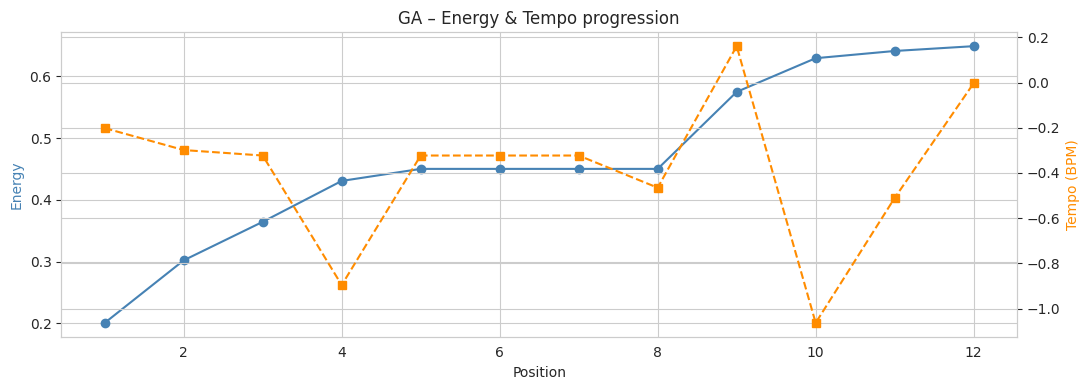

In [219]:
ga_score, ga_comps = total_playlist_score(df, X, seed_pos, best_individual)

print("=== Genetic Algorithm – Best Playlist ===")
print("Component scores:", {k: round(v, 3) for k, v in ga_comps.items()})
show_playlist(df, best_individual, title="GA Optimized Playlist")
plot_energy_tempo(df, best_individual, title="GA – Energy & Tempo progression")

## 10. Compare with Baselines (quick)

Comparison of Methods

| Method              | Strengths                          | Weaknesses |
|---------------------|------------------------------------|----------|
| Random              | Baseline                           | Very poor quality |
| Nearest Neighbor    | High seed similarity               | Low diversity & poor flow |
| Genetic Algorithm   | Good global exploration            | Can be slow, needs tuning |
| Simulated Annealing | Excellent local refinement         | Can get stuck without good start |

**Best practice**: Use GA for exploration → then refine the best solution with Simulated Annealing (Hybrid approach).

,smoothness,seed_similarity,diversity,mood_consistency,total
method,,,,,
Random,0.732,0.111,0.881,0.167,0.498
Nearest-Neighbor,0.920,0.946,0.064,0.417,0.638
Genetic Algorithm,0.973,0.509,0.754,0.750,0.746


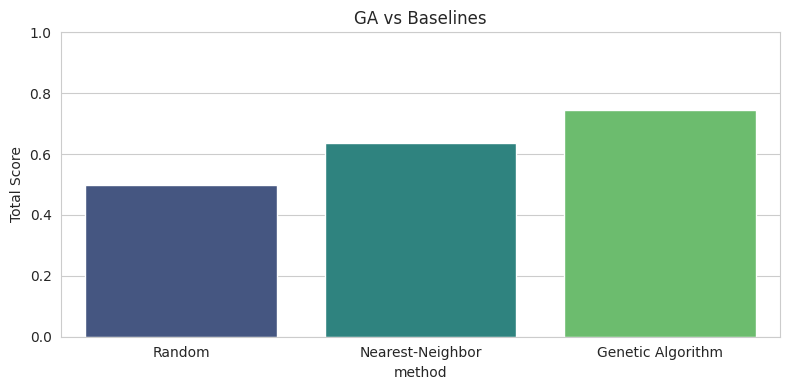

In [220]:
def random_playlist(n_tracks, length, seed_idx, random_state=42):
    rng = np.random.default_rng(random_state)
    candidates = np.delete(np.arange(n_tracks), seed_idx)
    return rng.choice(candidates, size=length, replace=False).tolist()

def nn_playlist(X, seed_idx, length):
    sims = cosine_similarity(X[seed_idx].reshape(1, -1), X)[0]
    sims[seed_idx] = -np.inf
    return np.argsort(sims)[-length:][::-1].tolist()

rand_idx = random_playlist(n_tracks, PLAYLIST_LENGTH, seed_pos)
nn_idx   = nn_playlist(X, seed_pos, PLAYLIST_LENGTH)

rand_score, rand_comps = total_playlist_score(df, X, seed_pos, rand_idx)
nn_score, nn_comps     = total_playlist_score(df, X, seed_pos, nn_idx)

comparison = pd.DataFrame([
    {"method": "Random",            **{k: round(v, 3) for k, v in rand_comps.items()}},
    {"method": "Nearest-Neighbor",  **{k: round(v, 3) for k, v in nn_comps.items()}},
    {"method": "Genetic Algorithm", **{k: round(v, 3) for k, v in ga_comps.items()}},
]).set_index("method")

display(comparison)

plt.figure(figsize=(8, 4))
sns.barplot(x=comparison.index, y=comparison["total"], palette="viridis")
plt.ylabel("Total Score")
plt.title("GA vs Baselines")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 11. Summary

- Chromosome = ordered list of unique track indices  
- Fitness = weighted sum of smoothness, seed similarity, diversity, mood consistency  
- Operators = tournament selection + Order Crossover + swap/replace mutation + elitism  
- GA improves over pure nearest-neighbor by trading a bit of pure similarity for better flow and diversity  

**Next**: `04_simulated_annealing.ipynb` (local-search style optimizer + final comparison)

## 12. (Optional) Save GA result

In [221]:
os.makedirs("data", exist_ok=True)
joblib.dump(
    {
        "best_individual": best_individual,
        "best_fitness": best_fitness,
        "history_best": best_fitness_history,
        "history_mean": mean_fitness_history,
        "seed_pos": seed_pos,
        "playlist_length": PLAYLIST_LENGTH,
    },
    "data/ga_result.pkl"
)
print("Saved data/ga_result.pkl")

Saved data/ga_result.pkl


## 13. Learning Notes – Genetic Algorithm for Playlist Optimization

### Problem Definition
We want to create an **ordered playlist** of fixed length (12 tracks) starting from a seed song.

The playlist should balance four objectives:
- **Smoothness**: Gradual change in energy and tempo (good flow)
- **Seed Similarity**: Tracks should be similar to the seed song
- **Diversity**: Avoid too many very similar songs
- **Mood Consistency**: Prefer tracks with the same mood as the seed

This is a **combinatorial optimization** problem (permutation + subset selection).

### Why Genetic Algorithm?
The search space is extremely large (combinatorial). GA is good at balancing exploration and exploitation.

### Key Design Choices
- **Representation**: List of unique track indices
- **Selection**: Tournament Selection
- **Crossover**: Order Crossover (OX) → preserves order & uniqueness
- **Mutation**: Swap + Replace
- **Elitism**: Keep top solutions every generation

### Common Problems We Faced & Fixes

| Problem                        | Cause                              | Solution |
|--------------------------------|------------------------------------|----------|
| Fitness = `-inf`               | Invalid individuals / NaNs         | Added safe fitness function |
| `TypeError: non-integer key`   | `None` values from crossover       | Made Order Crossover safer |
| Smoothness = `NaN`             | Missing energy/tempo values        | Used `np.nan_to_num` + median fill |
| Stuck in local minima          | Low diversity                      | Tuned mutation + tournament size |
| Bad seed track                 | Kidz Bop version selected          | Filtered low popularity + Kidz Bop |

---

### Important Lessons
1. Always make the fitness function safe (handle NaNs and invalid individuals).
2. Mutation rate is critical — too low → stuck in local optima, too high → random search.
3. Seed track quality strongly affects results (avoid low-popularity / cover versions).
4. Elitism helps prevent losing good solutions.
5. Logging best & average fitness helps detect premature convergence.

### Method Comparison
- **Random**: Baseline (poor)
- **Nearest Neighbor**: High similarity, weak diversity & flow
- **Genetic Algorithm**: Strong global exploration
- **Simulated Annealing**: Strong local refinement

**Best approach**: Use GA for exploration, then refine with Simulated Annealing.